# Project Overview

The goal of this project is to build an end-to-end content-based Recommender System (RS) for video games using a dataset of over 120,000 PC video games available on Steam Along the way, we answer several insightful business questions. Finally, we deploy the recommender system as an app using Streamlit. 

**[data_business.ipynb](./data_business.ipynb)**: Walks through the entire data science pipeline: from raw metadata cleaning and exploratory data analysis to answering key business insights.

**[recommender.ipynb](./recommender.ipynb)**: Covers the design and execution of the RS architecture, followed by both qualitative evaluation (relevance and serendipity) and quantitative evaluation (using Recall, ILD and novelty.)

**[app.py](../app.py)**: Deploys the production ready recommendation algorithm as a web application to Streamlit. 

**Interactive Web App**: You can test the live recommender here: [Steam Games Recommender](https://shujoshi-steam-recommender.streamlit.app/).

- [$\Phi$. Business Questions](#$\Phi$.-Business-Questions)
- [i. Data](#i.-Data)
    - [1. Initial Impression](#i.1.-Initial-Impression)
    - [2. Feature Alignment](#i.2.-Feature-Alignment)
    - [3. Feature Pruning](#i.3.-Feature-Pruning)
    - [4. Feature Engineering](#i.4.-Feature-Engineering)
        - [x. A Bayesian Approach to Creating a New Feature](#i.4.x.-A-Bayesian-Approach-to-Creating-a-New-Feature)
    - [5. Categorical Features](#i.5.-Categorical-Features)
        - [x. One Hot Encoding](#i.5.x.-One-Hot-Encoding)
    - [6. Data Filtering](#i.6.-Data-Filtering)
    - [7. Dropping Exhausted Features](#i.7.-Dropping-Exhausted-Features)
    - [8. Final Features](#i.8.-Final-Features)
- [ii. Strategic Business Insights](#ii.-Strategic-Business-Insights)
    - [Q1. Market Share & Revenue Analysis](#q1.-market-share--revenue-analysis)
    - [Q2. User Ratings vs. Financial Success](#q2.-user-ratings-vs-financial-success)
    - [Q3. The Financial Impact of DLC](#q3.-the-financial-impact-of-dlc)
    - [Q4. Low-Budget Indie Developer Strategy](#q4.-low-budget-indie-developer-strategy)
    - [Q5. Optimal Pricing Tiers](#q5.-optimal-pricing-tiers)
    - [Q6. Customer Sentiment via Gameplay Elements](#q6.-gameplay-element-feature-bundling)
- [iii. Next Steps](#iii.-Next-Steps)

# $\Phi$. Business Questions

After cleaning up the dataset, we will explore the following business questions that this dataset will help us answer.

    1. Which paid and free-to-play games achieve the highest market share in terms of estimated revenue and estimated owners respectively?
    2. How well do positive ratings by users correlate with the revenue generated by a paid game?
    3. How well have paid games that offer downloadable content (DLC) performed financially? Conversely, do most of the financially successful games offer DLC?
    4. Suppose an indie game developer with a modest budget plans to develop a game. Which genres should they look towards to maximize financial success while minimizing competition?
    5. What are the optimal pricing tiers to maximize player acquisition versus maximizing gross revenue?
    6. Which combination of gameplay elements (e.g., Single-player, Online Co-op, Steam Achievements) yields the highest customer sentiment?

    Along the way, we will visualize the data we're working with.

# i. Data

The data we'll use is taken from Kaggle, available: [here](https://www.kaggle.com/datasets/fronkongames/steam-games-dataset). This dataset is fairly large: 122,611 rows (games/rows) and 39 features (columns). Because raw metadata scraped directly from an API can be very messy, we will spend a fair bit of time making the data usable. Broadly:

1. **Feature Alignment:** Fixing structurally shifted rows.
2. **Feature Pruning:** Dropping columns that carry no useful data for our purpose.
3. **Content Filtering:** Exclude games with overly explicit themes to maintain content quality. Similarly, games with overly short/long names and Playtests are dropped.
4. **Feature Engineering:** Redefining existing features and creating entirely new features.



## i.1. Initial Impression

Let's begin by loading the data and exploring what it looks like.

In [328]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import re
import random
import streamlit as st

from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option('display.max_columns', None) # Display any number of columns.

In [329]:
df = pd.read_csv('C:/Python/Data Science Projects/Data/games.csv') 

In [330]:
df.info()

<class 'pandas.DataFrame'>
Index: 122611 entries, 2539430 to 4141790
Data columns (total 39 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AppID                       122610 non-null  str    
 1   Name                        122611 non-null  str    
 2   Release date                122611 non-null  str    
 3   Estimated owners            122611 non-null  int64  
 4   Peak CCU                    122611 non-null  int64  
 5   Required age                122611 non-null  float64
 6   Price                       122611 non-null  int64  
 7   DiscountDLC count           122611 non-null  int64  
 8   About the game              114162 non-null  str    
 9   Supported languages         122611 non-null  str    
 10  Full audio languages        122611 non-null  str    
 11  Reviews                     12070 non-null   str    
 12  Header image                122530 non-null  str    
 13  Website                

In [331]:
df.sample(5)

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2262910,That Last Girl,"Feb 12, 2023",0 - 20000,0,0,4.99,0,0,A challenging horror game versus an intelligen...,['English'],['English'],“it was a nice surprise to play a game like th...,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,jasondove@hotmail.com,True,False,False,0,NaN,0,6,3,NaN,0,0,"There's a few dead bodies, one of which could ...",0,0,0,0,Scry Business Intelligence Ltd,Scry Business Intelligence Ltd,"Single-player,Family Sharing",Indie,"Horror,Dark,Survival Horror,Psychological Horr...",https://shared.akamai.steamstatic.com/store_it...,NaN
1882040,Craft Hero,"Oct 9, 2022",50000 - 100000,1,0,2.49,50,1,"Become the last hope of humanity, rally the vi...","['English', 'Japanese', 'Simplified Chinese', ...",[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,okjoystudio@outlook.com,True,False,False,0,NaN,0,326,62,NaN,58,355,NaN,293,0,307,0,PandaCat 熊喵独立游戏,OKJOY,"Single-player,Steam Achievements,Partial Contr...","Adventure,Indie,RPG,Simulation,Strategy","Base-Building,Crafting,Sandbox,Survival,Simula...",https://shared.akamai.steamstatic.com/store_it...,NaN
1951480,Researchity | Open World Survival Game,"Jun 10, 2022",20000 - 50000,0,0,34.99,0,0,A Strange New Planet You receive a strange sig...,['English'],['English'],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,https://github.com/CBGameDev/Researchity/issues,Chris@QikPOS.co.uk,True,False,False,0,NaN,0,0,1,NaN,0,0,NaN,0,0,0,0,TheGameMill,TheGameMill,"Single-player,Family Sharing","Action,Adventure,Indie,RPG,Simulation,Strategy...","Early Access,Choose Your Own Adventure,Explora...",https://shared.akamai.steamstatic.com/store_it...,NaN
2906730,Watchword,"Sep 15, 2025",0 - 20000,0,0,11.19,20,0,Watchword is a roguelike deck builder about pl...,['English'],['English'],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,bigquailgames@gmail.com,True,True,True,0,NaN,0,0,0,NaN,17,0,NaN,0,0,0,0,Big Quail Games,Big Quail Games,"Single-player,Steam Achievements,Steam Cloud,F...","Casual,Indie,Strategy",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3822740,Tactical2,"Aug 30, 2025",0 - 0,0,0,0.00,0,0,Tactical2 is a turn-based strategy board game ...,['English'],[],NaN,https://shared.akamai.steamstatic.com/store_it...,https://tactical2.com,NaN,tactica2@dvisionlab.com,True,False,False,0,NaN,0,0,0,NaN,0,0,"The game is about character combat, although t...",0,0,0,0,D/Vision Lab s.r.l.,D/Vision Lab s.r.l.,"Multi-player,PvP,Online PvP","Strategy,Free To Play,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


We observe that there are several issues with this dataset.

1. The names of the first nine features (columns) are incorrectly aligned. In particular, the feature "DiscountDLC count" should be two separate features. 
2. While the feature AppID can serve as a unique datapoint (row) identifier, we will reindex the rows using positive integers.
3. We drop features that don't contain useful data or too many NaN values. In particular, several features contain only URL that are of no use. 
4. We will repurpose some features and engineer new ones from old features.
5. Features like "Categories" and "Tags" are of utmost important for our recommender system and we will need to preprocess these features, among others.
6. Etcetra... 

We will address games (rows) at a later time.

## i.2. Feature Alignment 

Let's rename the columns so the first nine features actually match the data they're supposed to represent. 

In [332]:
df.columns

Index(['AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'DiscountDLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies'],
      dtype='str')

In [333]:
df.columns = ['Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'Discount', 'DLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies']

Let's add an index to the dataset and rename the first feature as "AppID", which is what the original index of the dataset is supposed to be. The App ID of a game is a unique number that identifies that game. We will use it below to create a new feature: the URL to the game's Steam webpage. 

In [334]:
df = df.reset_index(drop = False) # Add a column that indexes the rows using positive integers.
df.index = df.index + 1

df = df.rename(columns={'index': 'AppID'}) # Rename the original index as "AppID".

In [335]:
df.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
1,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,NaN,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
2,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],[],NaN,https://shared.akamai.steamstatic.com/store_it...,http://mangagamer.org/supipara,http://mangagamer.com,support@mangagamer.com,True,False,False,0,NaN,0,252,3,NaN,0,231,NaN,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
3,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",[],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.facebook.com/8FloorGames/,https://www.facebook.com/8FloorGames,support@8floor.net,True,True,False,0,NaN,0,21,3,NaN,0,0,NaN,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
4,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],['Korean'],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,yujingamesc@gmail.com,True,False,False,0,NaN,0,0,0,NaN,19,0,The game includes the following elements. 1. G...,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
5,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],['English'],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.realityexpanded.com/books-games,https://www.realityexpanded.com,support@realityexpanded.com,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


## i.3. Feature Pruning

We begin by dropping features that will serve us no purpose. We list them below and provide brief reasoning for dropping them.

1. **Peak CCU**: This feature is too sparse to be useful. It's meant to be a feature indicating a game's performance and engagement. We will use other features for these metrics that are more robust and reliable. 
2. **Required age**: We assume that any user of our recommender system is an adult. Moreover, this feature is highly unreliable: many game developers enter required age as "0" even though the game may contain elements that are inappropriate for younger gamers. Additionally, we don't intend to use this feature in any of our business analysis. To make up for the loss of this, we will drop games that contain undesired elements. See [Jump to Section](#Removing-games-with-undesired-elements)
3. **Discount**: This is the feature that was tangled up with its neighbor, "DLC count" and the dataset documentation on Kaggle simply does not give information on this feature. It could be interpreted in many ways: Is it the discount % of the game at the time the dataset was created, or is it the maximum discount the game has ever seen?, etc. As such, it is impossible to include this feature in any analysis and we therefore, reluctantly, drop it.
4. **Supported languages**: A list of languages whose text is supported in a given game. Indie developers often have small budgets and this is where they cut costs. As such this feature does not give us a measure of the quality or performance of a game and so we drop it. 
5. **Full audio languages**: A list of audio languages a game supports. Niche or low budget indie games often cannot support audio in foreign languages. As such this feature is not an indicator of quality of a game, only its production budget. 
6. **Website**: We will delete this feature that contains a lot of NaN fields. Instead we will create a new feature with the same name that will give the Steam webpage of a game in our recommender system.
7. **Support URL, Support email**: Links for owners of a game to get service and support. These features are not useful to us.
8. **Windows, Mac, Linux**: Boolean features telling us whether a game is supported for the given operating system. We notice below that almost all games are supported on Windows and there are only 32 games for Mac that don't run on Windows. As such, since most games are supported on Windows, we will simply get rid of these features. If our recommender ends up recommending a Linux only game to a Windows user, we trust the user will check the requirements to run the game on their computer.  
9. **Metacritic score, Metacritic url**: The vast majority of the feature "Metacritic score" is 0; this is a sparse feature. This means there is no data available. We can safely drop this feature. We also have no purpose of the corresponding URL feature.
10. **User score, user rank**: Note below that there are only 40 games that have non-zero "User score"; another sparse feature. We will also drop is statistically insignificant feature. This will affect the feature "Score rank" which is supposed to be a relative ranking of games based on "User score". As we see below, 'Score rank' contains no useful data and so we drop it as well.
11. **Achievements**: Gives the number of achievements a game offers. This number is highly unreliable. Many games offer a large number of achievements to attract gamers but the game itself lacks quality. On the other hand 100 achievements in Racing might be significantly easier (or harder) than 100 achievements in Puzzle or RPG games. As such, we don't see a way to meaningfully use this feature and therefore drop it.
12. **Recommendations**: Gives the number of recommendations a game has received across Steam's community features using the outdated Steamworks API. As we see below, this feature is very rare: about 83% values are zero. We also see that for the most popular games, this feature is highly (Pearson) correlated with "Positive". Lastly, the non-zero values of this features starts off at 101, which is rather curious. As such we drop this feature in favor of the more robust "Positive" which will be used below to create the new feature "Vote percent".
13. **Average/Median playtime forever**: These features are identical as we see below. We drop Average playtime forever and keep the latter. 
14. **Average playtime two weeks, Median playtime two weeks**: These two features are less reliable than their "forever" counterparts. They measure a game's activity for a very short duration of time. As such, the "forever" playtime metrics are better indicators of a game's engagement and we therefore drop these inferior features.
15. **Screenshots**: A link to a game's screenshots. Not a useful feature for us.
16. **Movies**: Contains no data; all entries are NaN. 


In [336]:
# Notice that many features are strings that are URL. Most of these are not useful to us.

df.iloc[0:5, 11:16]

,Full audio languages,Reviews,Header image,Website,Support url
1,[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN
2,[],NaN,https://shared.akamai.steamstatic.com/store_it...,http://mangagamer.org/supipara,http://mangagamer.com
3,[],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.facebook.com/8FloorGames/,https://www.facebook.com/8FloorGames
4,['Korean'],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN
5,['English'],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.realityexpanded.com/books-games,https://www.realityexpanded.com


In [337]:
# Most games run on Windows while the number of games that run on Mac or Linux but not on Windows is negligible. 

no_windows = (df['Windows'] == False).sum() / len(df) * 100
print(f"The percentage of games that don't run on Windows is {no_windows:.2f}%.")

linux_no_windows = (df[(df['Linux'] == True) & (df['Windows'] == False)].shape[0]) / len(df) * 100
print(f"The percentage of games that run on Linux but not on Windows is {linux_no_windows:.2f}%.")

mac_no_windows = (df[(df['Mac'] == True) & (df['Windows'] == False)].shape[0]) / len(df) * 100 
print(f"The percentage of games that run on Mac but not on Windows is {mac_no_windows:.2f}%.")

The percentage of games that don't run on Windows is 0.04%.
The percentage of games that run on Linux but not on Windows is 0.01%.
The percentage of games that run on Mac but not on Windows is 0.03%.


In [338]:
# A function that gives the percentage of games with a value of zero (unavailable data) for a given feature. 

def percent_zero_values(data, feature):
    percentage_zero_values = ((data[feature] == 0).sum()) / len(data) * 100
    print(f"The feature {feature} has {percentage_zero_values:.2f}% data values equal to zero.")

In [339]:
percent_zero_values(df, 'Peak CCU')
percent_zero_values(df, 'Metacritic score')
percent_zero_values(df, 'User score') # As a consequence, "Score rank" is a meaningless feature. 

The feature Peak CCU has 83.95% data values equal to zero.
The feature Metacritic score has 96.53% data values equal to zero.
The feature User score has 99.97% data values equal to zero.


In [340]:
# Average and median playtime forever are identical features. 

print((df['Average playtime forever'] != 0).sum())
print((df['Median playtime forever'] != 0).sum())
print(((df['Average playtime forever'] != 0) & (df['Median playtime forever'] != 0)).sum())
print('The above three numbers are identical, i.e., these features are non-zero for the exact same subset of games.')

# Now let's check their linear correlation. It is practically 1. 

pearson_corr = (df['Average playtime forever']).corr((df['Median playtime forever']), method = 'pearson')
print(f'The Pearson correlation of these features is {pearson_corr:.5f}.')

26119
26119
26119
The above three numbers are identical, i.e., these features are non-zero for the exact same subset of games.
The Pearson correlation of these features is 0.99421.


In [341]:
# We explore Recommendations to study its feature space.

n = ((df['Recommendations'] == 0).sum() / df.shape[0]) * 100            # About 83% of "Recommendations" is 0. 
print(f"The percentage of games with zero Recommendations is {n:.2f}.")

smallest_rec_values = sorted(df['Recommendations'].astype(object).unique())[:5]     # Notice that the non-zero recommendations start at 101. 
print(f"The five smallest Recommendation values are", *smallest_rec_values, sep = " ")

# Calculate both correlation matrices

pearson_corr = df['Positive'].corr(df['Recommendations'], method='pearson')
spearman_corr = df['Positive'].corr(df['Recommendations'], method='spearman')

print(f"Pearson Correlation (Linear): {pearson_corr:.4f}") # Positive and Recommendations are highly (Pearson) correlated. 
print(f"Spearman Correlation (Rank): {spearman_corr:.4f}")

The percentage of games with zero Recommendations is 82.95.
The five smallest Recommendation values are 0 101 102 103 104
Pearson Correlation (Linear): 0.9018
Spearman Correlation (Rank): 0.5368


In [342]:
# The feature Movies contains no data.

df['Movies'].notnull().astype(object).sum()

0

**Dropping Features**: We now drop all columns we wish to at the same time and take a look at what our data now looks like. Note that we are not entirely done with dropping features. We will use certain features like "About the game", "Reviews" and "AppID" and then drop them once their usage is exhausted. 

In [343]:
# Function for dropping features.

def drop_columns(data, cols):
    return data.drop(columns = cols)

In [344]:
cols = ['Peak CCU', 'Required age', 'Discount', 'Supported languages', 'Full audio languages', 'Website', 'Support url', 'Support email', 'Windows', 'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 
                   'User score', 'Score rank', 'Average playtime two weeks', 'Median playtime two weeks', 'Average playtime forever', 'Achievements', 'Recommendations', 'Screenshots', 'Movies']
df = drop_columns(df, cols)

In [345]:
df = df.reset_index(drop = True) 
df.index = df.index + 1

In [346]:
df.head()

,AppID,Name,Release date,Estimated owners,Price,DLC count,About the game,Reviews,Header image,Positive,Negative,Notes,Median playtime forever,Developers,Publishers,Categories,Genres,Tags
1,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0.00,0,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
2,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,5.24,0,"Springtime, April: when the cherry trees come ...",NaN,https://shared.akamai.steamstatic.com/store_it...,252,3,NaN,8,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute"
3,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,4.99,0,"Immerse yourself in the most beloved, mystical...",NaN,https://shared.akamai.steamstatic.com/store_it...,21,3,NaN,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec..."
4,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,8.99,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",NaN,https://shared.akamai.steamstatic.com/store_it...,0,0,The game includes the following elements. 1. G...,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN
5,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,4.99,0,Its not just a Maze; its a Quest! Enter the ca...,NaN,https://shared.akamai.steamstatic.com/store_it...,0,0,NaN,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN


## i.4. **Feature Engineering** 

We now clean some features and create a few new useful features using the ones we already have.

**Release date**: We convert release date to a consistent format: YYYY-MM-DD and make sure that there are no errors, for example, 2028-20-41.  

In [347]:
nat_count = df['Release date'].isna().sum()
print(f"Total NaT values in Release date: {nat_count}")

Total NaT values in Release date: 0


In [348]:
# Convert Release date to the default pandas format: datetime64[ns] displayed as YYYY-MM-DD.
df['Release date'] = pd.to_datetime(df['Release date'], errors = 'coerce') 

years = df['Release date'].dt.year.unique().tolist() # Make sure the year of release falls within in the expected range.
print(f'The list of years in which a game was released is', sorted(years))

months = df['Release date'].dt.month.unique().tolist() # Make sure the month of release falls within the expected range
print(f'The list of months in which a game was released is', sorted(months))

days = df['Release date'].dt.day.unique().tolist() # Make sure the day of release falls within the expected range .
print(f'The list of days of a month on which a game was released is', sorted(days))

The list of years in which a game was released is [1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
The list of months in which a game was released is [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
The list of days of a month on which a game was released is [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]


"Release date" is now in a consistent format and all numbers representing a date fall within the expected range.

**New Feature: Game age**: We create this new feature that will help us normalize revenue generated by a game per year later on. We require this feature to be in number of years accurate to two decimal places. Since every fourth year has 366 days, it will be slightly more appropriate to use a year as 365.25 days below. Please note that Game age is calculated with respect to the date this code was written: May 6, 2026. :)

In [349]:
from datetime import date

today = pd.Timestamp('2026-05-06')

df['Game age'] = ((today - df['Release date']) / pd.Timedelta(days = 365.25)).round(2)

Let us verify that this feature is producing the age of a game as expected. The game [Stardew Valley](https://store.steampowered.com/app/413150/Stardew_Valley/) came out in Feb, 2016, so the expected age of this game is a little more than 10 years. 

In [350]:
print(df.loc[df['Name'] == 'Stardew Valley', 'Game age']) # The output below is as expected. 

95881    10.19
Name: Game age, dtype: float64


**New Feature: Website**: It gives the URL of the Steam webpage of a game. We use the feature "AppID" to construct this feature, which contains no NaN objects, so we are ready to use it. This is the correct way to record a game's Steam URL. Steam uses a consistent URL format for all games as outlined in the code below. 

In [351]:
df['Website'] = 'https://store.steampowered.com/app/' + df['AppID'].astype(str) + '/' 

df.loc[df['Name'] == 'The Talos Principle', 'Website'] # Go ahead and check out this game by clicking the link below. It's awesome!

53776    https://store.steampowered.com/app/257510/
Name: Website, dtype: str

**Redefining Estimated owners**: This feature is a string that gives an estimated range of the number of owners of a game. We will use this range to get an estimate of the number of owners as one single number. In this case, we choose this estimate to be the mean of the range. The mean is a crude but appropriate measure of central tendency in this scenario. The main purpose of this feature is to help estimate yearly revenue generated by a game. 

In [352]:
# Split Estimated owners column into two temporary columns
owners_split = df['Estimated owners'].str.split('-', expand=True).astype(float)

# Calculate the average
df['Estimated owners'] = (owners_split[0] + owners_split[1]) / 2

**New Feature: Estimated yearly revenue**: We would like to get an estimate of the revenue generated per year by each game. To do this, we define Estimated revenue = (Average owners X Price) / Game age. We keep in mind the following facts about game pricing in mind:

1. Since "Price" is in USD, we are ignoring the fact that games are also bought by people outside the US using currencies different from the USD.
2. Many games go on discount a few times a year so the actual revenue generated is typically lower.
3. Steam takes a cut from the price a buyer pays for a game so the actual revenue a game developer generates is smaller. Similarly, several other "middle men" take their cut, for example, the game publisher, game promoters, etc.
4. There are "fremium" games. These games are free to download and play but may inlude paid additional content.
5. Many modern games have DLCs, i.e., domnloadble content which is typically paid and may generate revenue beyond the original purchase of the game. 
6. Lastly, the entries in the feature "Price" are proabably recorded at the time this dataset was created and the typical price of a game may fluctuate over time.
   
Of course, this is far from an ideal estimate, but nonetheless, "Estimated revenue" will give us an indication of how a paid game has performed financially. We keep in mind that "Estimated revenue" will typically be a gross upper bound of the actual revenue generated by the game. 

In [353]:
df['Estimated yearly revenue'] = (df['Estimated owners'] * df['Price']) / df['Game age']

In [354]:
df['Estimated yearly revenue'].describe()

count    1.226110e+05
mean     1.977631e+05
std      9.827168e+06
min      0.000000e+00
25%      0.000000e+00
50%      6.939252e+03
75%      2.806370e+04
max      2.631140e+09
Name: Estimated yearly revenue, dtype: float64

Now observe that "Estimated yearly revenue" has a large range. We will therefore use a logrithm tranform to better represent revenue. Next, we need all our values between 0 and 1 so we use the MinMaxScaler to achieve this. It is obvious why one shouldn't directly apply MinMaxScaler without the log transform. For convenience sake, we preserve the name of this feature, even though we are transforming it. 

In [355]:
df['Estimated yearly revenue'] = np.log10(df['Estimated yearly revenue'] + 1) # We add 1 since log 0 is undefined. This gives a nice consistent scale from 0 to around 9.

df['Estimated yearly revenue'] = MinMaxScaler().fit_transform(df[['Estimated yearly revenue']]) # Apply the MinMaxScaler

df['Estimated yearly revenue'].describe()

count    122611.000000
mean          0.331742
std           0.206499
min           0.000000
25%           0.000000
50%           0.407783
75%           0.472197
max           1.000000
Name: Estimated yearly revenue, dtype: float64

Let's reorder the games by "Estimated yearly revenue" in descending to see if we recognize some of the games and list out the top 20 games by yearly revenue. This seems like a more appropriate head for this dataset!

In [356]:
df = df.sort_values(by = 'Estimated yearly revenue', ascending = False); # Sort the games by yearly revenue.

df = df.reset_index(drop = True) # Reset index 
df.index = df.index + 1

Let's see the top twenty games by Estimated yearly revenue. 

In [357]:
df.iloc[0:20, 1] 

1              Black Myth: Wukong
2            Monster Hunter Wilds
3             New World: Aeternum
4                 Path of Exile 2
5                        Palworld
6                 Baldur's Gate 3
7                   HELLDIVERS™ 2
8                      Last Epoch
9                EA SPORTS FC™ 25
10                     ELDEN RING
11                   Satisfactory
12                  7 Days to Die
13              Battlefield™ 2042
14                     Schedule I
15                           SCUM
16                      CyberCorp
17                 Cyberpunk 2077
18    Clair Obscur: Expedition 33
19                 Battlefield™ V
20                       Hades II
Name: Name, dtype: str

In [358]:
# A function to plot the distribution of a continuous feature as histogram. 

def plot_feature(dataframe, feature, title, xlabel, ylabel):
    sns.set_theme(style = 'whitegrid')
    plt.figure(figsize = (16,6))
    sns.histplot(data = dataframe, x = feature, bins = 50, kde = False) 
    plt.xlabel(xlabel, fontsize = 12)
    plt.ylabel(ylabel, fontsize = 12)
    plt.show()

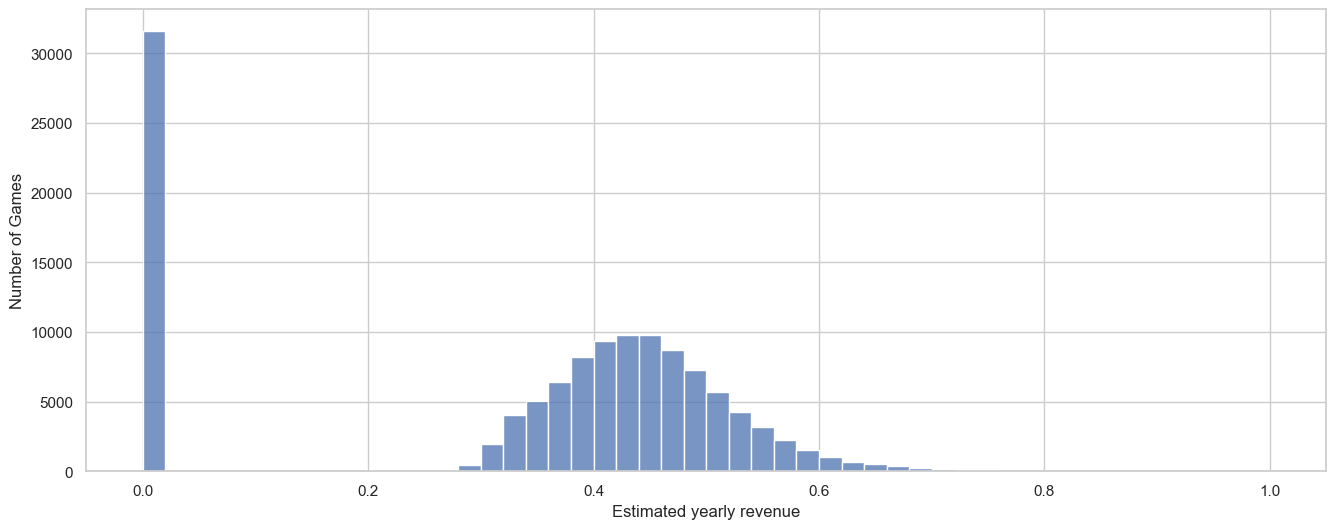

In [359]:
plot_feature(df, 'Estimated yearly revenue', 'Distribution of Estimated yearly revenue', 'Estimated yearly revenue', 'Number of Games')

As expected, ignoring the free to play games, the rest of the data follows a normal distribution. 

Now we also scale the feature Estimated owners. Like before, we'll first apply a log-transform and then the MinMaxScaler. The reason is that without the log-transform, MinMaxScaler will squash the majority of the games with fewer owners close to zero. 

In [360]:
df['Estimated owners'] = np.log10(df['Estimated owners'] + 1) # We add 1 since log 0 is undefined. This gives a nice consistent scale from 0 to around 9.

df['Estimated owners'] = MinMaxScaler().fit_transform(df[['Estimated owners']]) # Apply the MinMaxScaler

In [361]:
df['Estimated owners'].describe()

count    122611.000000
mean          0.427640
std           0.205606
min           0.000000
25%           0.489237
50%           0.489237
75%           0.489237
max           1.000000
Name: Estimated owners, dtype: float64

**New Feature: Vote Percent**: This feature gives positive votes as a percentage of total votes. We use the features "Positive" and "Negative" to do this. This operation will return NaN precisely when there are no positive or negative votes. In this case, we will set the vote percent of such a game to 0.  

In [362]:
df['Vote percent'] = df['Positive'] / (df['Positive'] + df['Negative']) * 100 

In [363]:
df['Vote percent'].isnull().sum() 

np.int64(39662)

In [364]:
df['Vote percent'] = df['Vote percent'].fillna(0) # Let's set NaN values to 0. We'll use Bayesian statsitics to rigorously address this later. 

As an example, let's check the Vote percent of the game [Stardew Valley](https://store.steampowered.com/app/413150/Stardew_Valley/). It's identical (rounded to the closest integer) to what you'll see on the Steam webpage for the game.

In [365]:
df.loc[df['Name'] == 'Stardew Valley', 'Vote percent']

78    98.441539
Name: Vote percent, dtype: float64

### i.4.x. A Bayesian Approach to Creating a New Feature

Suppose Game A has 3 positive votes and 0 negative votes. Its Vote percent is 100%. Suppose Game B has 10,000 positive votes and 720 negative votes. It's Vote percent is 93%. But raw ranking of games based on Vote percent will favor Game A over Game B. This is a huge problem since Game A lacks voting data. To rectify this, we employ a Bayesian approach to scale this feature so that in the above scenario, Game B is favored far heavier over Game A. 

Overview of the logic: 

1. Likelihood: The features Positive and Negative give us our Bayesian likelihood. Since a vote can be either positive or negative, we model votes using the binomial distribution.
2. Prior: This is what we believe the votes in our dataset behaves like on average. We want the values of scaled Vote percent to fall between 0 and 1. This scale is continuous. The Beta distribution is desgined precisely for such a scenario.

Objective: Given the Prior, we seek to obtain an updated probability (Posterior) based on available voting data (Likelihood). 




In [366]:
# Convert Vote percent to numbers between 0 and 1.

C = (df['Vote percent'] / 100).mean()

# We choose the median number of total votes as our volume threshold, i.e., the number of "ghost votes" we wish to weigh against games with a low volume of votes. 

m = (df['Positive'] + df['Negative']).median()

# Introduce Bayesian parameters.

a_global = m * C

b_global = m * (1 - C)

# Define the posterior. 

df['Bayesian votes'] = (df['Positive'] + a_global) / ((df['Positive'] + df['Negative']) + (b_global + a_global))

In [367]:
df['Bayesian votes'].describe() # A quick check to see the range is [0,1].

count    122611.000000
mean          0.632798
std           0.153858
min           0.105009
25%           0.512990
50%           0.575389
75%           0.756495
max           0.995773
Name: Bayesian votes, dtype: float64

In [368]:
df = df.sort_values(by = 'Bayesian votes', ascending = False) # Let's reorder the dataset by Bayesian votes. 

Here are the top 10 games by bayesian votes. Heading over to the Steam webpage for any of these games shows that it has overwhelmingly positive votes. 

In [369]:
df.iloc[0:10, 1]

8653                                         Kabuto Park
7301      Aokana - Four Rhythms Across the Blue - EXTRA2
119487                                   The WereCleaner
11811                              A Castle Full of Cats
15060                               A Tower Full of Cats
3028                                         Beastieball
2873                             Papa's Freezeria Deluxe
18136                                         Seal World
4722                             TOEM: A Photo Adventure
6002                                        A Short Hike
Name: Name, dtype: str

Here are the bottom 10 games by bayesian votes. Some of these games have no votes at al or have overwhelmingly negative votes.  

In [370]:
df.iloc[-10:, 1]

30020                         Chess
8925                Age of Survival
66946                10 Years After
38556                      Only Up!
53986                     CornField
71940      Heroes in the Sky-Origin
21650            PawnShop Simulator
37481    Construction Machines 2014
58121                 Drunk Wizards
8231                   SuperPower 3
Name: Name, dtype: str

**Case Study**: Let's find two games with similar Votes percent but one having significantly more total votes than the other. The Bayesian votes score for these should be drastically different. 

In [371]:
df.loc[((df['Positive'] == 3) & (df['Negative'] == 0)), 'Name'][:3]

83613                   GUIDE
56080            K'nife Fight
56109    Drops: Rhythm Garden
Name: Name, dtype: str

In [372]:
df.loc[((df['Positive'] == 96) & (df['Negative'] == 3)), 'Name'][:3]

78862                   Recollection
28901    The Mystery of Caketropolis
Name: Name, dtype: str

In [373]:
# Let's choose the games Alien Age and Recollection. Find their Vote percent

print(df.loc[df['Name'] == 'Alien Age', 'Vote percent'])
print(df.loc[df['Name'] == 'Recollection', 'Vote percent'])

11932    100.0
Name: Vote percent, dtype: float64
78862    96.969697
Name: Vote percent, dtype: float64


In [374]:
# Find their Bayesian votes now.

print(df.loc[df['Name'] == 'Alien Age', 'Bayesian votes'])
print(df.loc[df['Name'] == 'Recollection', 'Bayesian votes'])

11932    0.659093
Name: Bayesian votes, dtype: float64
78862    0.939537
Name: Bayesian votes, dtype: float64


**Conclusion**: Note that even though the game Alien Age has only 3 total votes, it has a 100% Vote percent whereas it's Bayesian votes score is ~0.66, which is close to the mean of the Bayesian votes feature. On the other hand, the game Recollection has a lower Votes percent but a significantly higher Bayesian votes score since it has a larger number of total votes, which makes its positive votes all the more precious. The feature Bayesian votes is working as expected. 

## i. 5. Categorical Features 

Data Dictionary: Label: Genres, Categories, Tags, Publishers and Developers are categorical features that contains lists of strings as objects. Each string in such a list will be termed a 'label'. 

### Genres, Categories & Tags

These are the most important categorical features in our project and they will strongly influence our recommender system. We start by cleaning and preprocessing them first.  

The function we define below gives a wondeful way to look at the feature space of a categorical variable holding lists of comma separated strings. 

In [375]:
# A function that prints out all the unique labels of a categorical feature that holds a list of strings. 

def unique_labels(data, feature):
    
    all_labels = []

    for entry in data[feature].dropna():
        labels = [g.strip().lower() for g in entry.split(",")]
        all_labels.extend(labels)

    unique_labels = sorted(set(all_labels))

    return unique_labels

We now take a look at "Genres", "Categories" and "Tags". These features are very important for constructing our recommender system. We see with a quick glance below that "Genres" looks fine but "Categories" and "Tags" deserves a closer look considering the large number of unique values it admits. 

In [376]:
print(unique_labels(df, 'Genres'))

['360 video', 'accounting', 'action', 'adventure', 'animation & modeling', 'audio production', 'casual', 'design & illustration', 'documentary', 'early access', 'education', 'episodic', 'free to play', 'game development', 'gore', 'indie', 'massively multiplayer', 'movie', 'nudity', 'photo editing', 'racing', 'rpg', 'sexual content', 'short', 'simulation', 'software training', 'sports', 'strategy', 'tutorial', 'utilities', 'video production', 'violent', 'web publishing']


In [377]:
print(unique_labels(df, 'Categories'))

['adjustable difficulty', 'adjustable text size', 'camera comfort', 'captions available', 'chat speech-to-text', 'chat text-to-speech', 'co-op', 'color alternatives', 'commentary available', 'cross-platform multiplayer', 'custom volume controls', 'family sharing', 'full controller support', 'hdr available', 'in-app purchases', 'includes level editor', 'includes source sdk', 'keyboard only option', 'lan co-op', 'lan pvp', 'mmo', 'mods', 'mods (require hl2)', 'mouse only option', 'multi-player', 'narrated game menus', 'online co-op', 'online pvp', 'partial controller support', 'playable without timed input', 'pvp', 'remote play on phone', 'remote play on tablet', 'remote play on tv', 'remote play together', 'save anytime', 'shared/split screen', 'shared/split screen co-op', 'shared/split screen pvp', 'single-player', 'stats', 'steam achievements', 'steam cloud', 'steam leaderboards', 'steam timeline', 'steam trading cards', 'steam turn notifications', 'steam workshop', 'steamvr collectib

Glancing over "Categories", we notice that most of it is fine except there are two entries "VR Supoort" and "VR Supported" that should be unfied to one: "VR Supported".

In [378]:
sorted(df.loc[df['Name'] == 'The Talos Principle', 'Tags'])

['Puzzle,Philosophical,First-Person,Sci-fi,Atmospheric,Story Rich,Singleplayer,Great Soundtrack,Robots,Exploration,Adventure,Indie,Multiple Endings,Difficult,Mystery,Post-apocalyptic,Action,Simulation,Science,Artificial Intelligence']

In [379]:
df["Categories"] = df['Categories'].str.replace(r'\bVR Support\b', 'VR Supported', regex = True)

Let's check that "VR Support" and "VR Supported" have been merged into "VR Supported". 

In [380]:
print(unique_labels(df, 'Categories'))

['adjustable difficulty', 'adjustable text size', 'camera comfort', 'captions available', 'chat speech-to-text', 'chat text-to-speech', 'co-op', 'color alternatives', 'commentary available', 'cross-platform multiplayer', 'custom volume controls', 'family sharing', 'full controller support', 'hdr available', 'in-app purchases', 'includes level editor', 'includes source sdk', 'keyboard only option', 'lan co-op', 'lan pvp', 'mmo', 'mods', 'mods (require hl2)', 'mouse only option', 'multi-player', 'narrated game menus', 'online co-op', 'online pvp', 'partial controller support', 'playable without timed input', 'pvp', 'remote play on phone', 'remote play on tablet', 'remote play on tv', 'remote play together', 'save anytime', 'shared/split screen', 'shared/split screen co-op', 'shared/split screen pvp', 'single-player', 'stats', 'steam achievements', 'steam cloud', 'steam leaderboards', 'steam timeline', 'steam trading cards', 'steam turn notifications', 'steam workshop', 'steamvr collectib

### Cleaning up Tags

In [381]:
print(unique_labels(df,'Tags'))

['1980s', "1990's", '2.5d', '2d', '2d fighter', '2d platformer', '360 video', '3d', '3d fighter', '3d platformer', '3d vision', '4 player local', '4x', '6dof', '8-bit music', 'abstract', 'action', 'action roguelike', 'action rpg', 'action rts', 'action-adventure', 'addictive', 'adventure', 'agriculture', 'aliens', 'alternate history', 'ambient', 'america', 'animation & modeling', 'anime', 'arcade', 'archery', 'arena shooter', 'artificial intelligence', 'assassin', 'asymmetric vr', 'asynchronous multiplayer', 'atmospheric', 'atv', 'audio production', 'auto battler', 'automation', 'automobile sim', 'base-building', 'baseball', 'based on a novel', 'basketball', 'batman', 'battle royale', "beat 'em up", 'beautiful', 'benchmark', 'bikes', 'birds', 'blood', 'bmx', 'board game', 'boomer shooter', 'boss rush', 'bowling', 'boxing', 'building', 'bullet hell', 'bullet time', 'capitalism', 'card battler', 'card game', 'cartoon', 'cartoony', 'casual', 'cats', 'character action game', 'character cus

Visually inspecting the feature space of "Tags" gives us an idea that the feature is *mostly* clean. Tags is a very important feature for Steam as a company, so it is not surprising that it is incredibly clean. Nonetheless, we do our due diligence to find any typos or redundant tags. This can be achieved by surfacing up the least used tags, since this is where typos usually live. 

In [382]:
# Clean the brackets/quotes and split the tags by commas into a list.
clean_tags = df['Tags'].str.replace(r"[\[\]']", "", regex=True).str.split(",")

# Explode the lists so every tag gets its own row, remove whitespace, and count them
tag_counts = clean_tags.explode().str.strip().value_counts()

# Find the threshold value for the bottom 10% of unique tags.
bottom_10_threshold = tag_counts.quantile(0.10)

# Filter out the tags that fall below or equal to this threshold.
noise_tags = tag_counts[tag_counts <= bottom_10_threshold]

print(f'The bottom 10% threshold is: {bottom_10_threshold} occurrences.')
print(f'Number of unique tags classified as noise: {len(noise_tags)}')
print('\nThe 10%  of least used Tags are:')
print(noise_tags.tail(len(noise_tags)))

The bottom 10% threshold is: 80.4 occurrences.
Number of unique tags classified as noise: 46

The 10%  of least used Tags are:
Tags
Boss Rush             80
Instrumental Music    80
Skateboarding         79
Motocross             79
Mod                   78
Lemmings              76
Hockey                75
Based On A Novel      74
Skating               72
Bowling               64
Warhammer 40K         55
Well-Written          54
BMX                   53
Skiing                52
8-bit Music           52
Shop Keeper           46
Rock Music            46
Snowboarding          44
Electronic            43
Voice Control         42
Dice                  40
ATV                   39
Extraction Shooter    38
Birds                 36
Musou                 36
TrackIR               35
Coding                33
Documentary           32
Fox                   30
Cricket               29
Masterpiece           28
Benchmark             27
Hardware              24
Volleyball            22
Rugby             

Verdict: We don't find any typos. More importantly, there aren't any tags that are meaningless or redundant and so we don't drop any tags. 

We now check whether there are any labels shared by Genres, Categories and Tags. This is easily achieved by recasting unique labels as a Python set. 

In [383]:
# Lets find the number of unique labels for these features. 

print('The number of unique Genres is', len(unique_labels(df, 'Genres')))
print('The number of unique Categories is', len(unique_labels(df, 'Categories')))
print('The number of unique Tags is', len(unique_labels(df, 'Tags')))   

The number of unique Genres is 33
The number of unique Categories is 57
The number of unique Tags is 452


In [384]:
set_genres = set(unique_labels(df, 'Genres')) 
set_categories = set(unique_labels(df, 'Categories'))
set_tags = set(unique_labels(df, 'Tags'))

In [385]:
genres_intersect_categories = set_genres & set_categories
print('The labels common to both Genres and Categories are', genres_intersect_categories) # set() is an empty set. 

The labels common to both Genres and Categories are set()


In [386]:
categories_intersect_tags = set_categories & set_tags
print('The labels common to both Categories and Tags are', categories_intersect_tags)

The labels common to both Categories and Tags are {'co-op', 'pvp', 'vr only', 'online co-op'}


In [387]:
genres_intersect_tags = set_genres & set_tags
print('The labels common to both Genres and Tags are', sorted(genres_intersect_tags))

The labels common to both Genres and Tags are ['360 video', 'action', 'adventure', 'animation & modeling', 'audio production', 'casual', 'design & illustration', 'documentary', 'early access', 'education', 'episodic', 'free to play', 'game development', 'gore', 'indie', 'massively multiplayer', 'movie', 'nudity', 'photo editing', 'racing', 'rpg', 'sexual content', 'short', 'simulation', 'software training', 'sports', 'strategy', 'tutorial', 'utilities', 'video production', 'violent', 'web publishing']


We have discovered that these features are not disjoint, they share certain labels. This is highly problematic if left untreated since one hot encoding will gives multiple features with the same name. This will artifically boost games in the recommender if a label appears in for example, both Genres and Tags.

**New Feature: Characteristics**: To address the above issue, we will create one master feature called "Characteristics" which will be a concatenation of Genres, Categories and Tags. We will then cast this feature as a set to eliminate duplicates and then recast it into a format that the CountVectorizer (our one hot encoder) accepts. 

In [388]:
# Function that merges categorical features and removes duplicate tags.

def unify_categorical_features(row, features):
    
    master_feature = []

    for feature in features:
        
        # Check if the cell has data (isn't NaN or empty).
        if pd.notna(row[feature]) and str(row[feature]).strip() != "":
            
            # Split the comma-separated string into individual labels.
            labels = [label.strip().replace(' ', '').lower() for label in str(row[feature]).split(',')]
            
            # Extend the master list with these labels.
            master_feature.extend(labels)

    # Convert to a set to remove duplicates, then join into a space-separated string.
    return ' '.join(set(master_feature))


In [389]:
target_features = ['Genres', 'Categories', 'Tags']

df['Characteristics'] = df.apply(unify_categorical_features, axis = 1, features = target_features)

Now lets investigate if Characteristics is welld defined by checking if it has any NaN values. 

In [390]:
df['Characteristics'].isnull().sum()

np.int64(0)

It seems Characteristics has no missing data but this should match with how we've defined the feature. There should be no games that miss Genres, Categories and Tags data simultaneously. We see below that this is not the case and we must address this discrepancy. 

In [391]:
missing_count = ((df['Genres'].isnull()) & (df['Categories'].isnull()) & (df['Tags'].isnull())).sum()
print('The number of games missing Genres, Categories and Tags data is', missing_count)

The number of games missing Genres, Categories and Tags data is 7984


In [392]:
# Find the list of games that's missing all three features (Genres, Categories and Tags) simultaneously. 

mask = df['Genres'].isnull() & df['Categories'].isnull() & df['Tags'].isnull()

# Filter the DataFrame
missing_all_three = df.loc[mask]
print(missing_all_three['Name'])

108766                              SteamVR Driver for FOVE
122588                      Interference: Dead Air Playtest
122591                           Codename: Warlock Playtest
122592                            A Stitch In Time Playtest
116163                                        Cato Playtest
                                ...                        
109855                                   Gladiator Playtest
109856                            The Glitch Fairy Playtest
109863                                     scuffed Playtest
109867                                        上学威龙 Playtest
109849    Captain Gazman Day Of The Rage - Development Beta
Name: Name, Length: 7984, dtype: str


**Removing Playtests**: We discover that there are a bunch of "Playtest games". These are beta trials of games that developers test on the Steam platform and as such are not real games. That is why they are lacking the metadata features Genres, Categories and Tags. We should absolutely drop them since they aren't real games, just noise in the dataset. 

In [393]:
df = df[~df['Name'].str.contains('playtest', case = False, na = False)]
print('We\'ve removed playtest builds. Number of games in dataset', len(df))

We've removed playtest builds. Number of games in dataset 114482


In [394]:
missing_count = ((df['Genres'].isnull()) & (df['Categories'].isnull()) & (df['Tags'].isnull())).sum()
print('The number of games missing Genres, Categories and Tags data is', missing_count)

The number of games missing Genres, Categories and Tags data is 129


In [395]:
# Create the mask and filter
mask = df['Genres'].isnull() & df['Categories'].isnull() & df['Tags'].isnull()
missing_all_three = df.loc[mask]

# Print the entire list of names without truncation
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(missing_all_three['Name'])

108766                              SteamVR Driver for FOVE
116260                      1428: Shadows over Silesia Beta
116089                                     BOBO ~In Animia~
116287                                          Events Beta
116343                                No Time To Die - Test
115949                              Star Pulse:The War-test
116706                      Millennium Strategy (Beta Test)
115174                                     IRON EVIL - Beta
117368                         Akuro & Bahaku 2 (DEMO BETA)
117508                                  Project Archipelago
114936                                     Eruption DevTest
117869                                    KILLER INN - BETA
117903                              OutcastKidsAndCity DEMO
114449                               Fablecraft Closed Beta
114283                                     Heroes Suck Beta
118349                              Polygon of Reality Beta
114194                                  

In [396]:
df.loc[df['Name'] == 'Beauty VS Zombie', 'Tags']

99202    NaN
Name: Tags, dtype: str

In [397]:
df.loc[df['Name'] == 'Beauty VS Zombie', 'Characteristics']

99202    
Name: Characteristics, dtype: str

In [398]:
# This regex pattern matches empty strings, pure spaces, or any combination of commas and spaces (basically, trash) and sets them to NaN.
df['Characteristics'] = df['Characteristics'].replace(r'^[,\s]*$', np.nan, regex = True)

# Check the missing count again to verify it worked.
new_missing_count = df['Characteristics'].isnull().sum()
print(f"Now, 'Characteristics' shows {new_missing_count} missing values.")

Now, 'Characteristics' shows 129 missing values.


The number of games missing Genres, Categories and Tags data simultaneously is 128, whereas now, Characteristics shows 192 missing values. This is still a discrepancy, but way smaller than the previous one.

We note that there are a small number (~100) of "games" containing the words "beta", "test", "demo". A lot of these are not real games but rather non-playable versions of games that developers test on Steam. We don't clean these up: the reason is that this noise is insignificant for our RS as these will not surface up as highly recommendable games anyway. Moreoever, there are actualk games contains these words (perhaps as subwords) that risk deletion if we decide to clean up this noise. 

In [399]:
# Get the unique words array
unique_words = df['Characteristics'].str.split().explode().unique()

# Drop anything that isn't a string (removes float nans).
clean_unique_words = [word for word in unique_words if isinstance(word, str)]

print(f"Total unique words: {len(clean_unique_words)}")
print(sorted(clean_unique_words))

Total unique words: 506
['1980s', "1990's", '2.5d', '2d', '2dfighter', '2dplatformer', '360video', '3d', '3dfighter', '3dplatformer', '3dvision', '4playerlocal', '4x', '6dof', '8-bitmusic', 'abstract', 'accounting', 'action', 'action-adventure', 'actionroguelike', 'actionrpg', 'actionrts', 'addictive', 'adjustabledifficulty', 'adjustabletextsize', 'adventure', 'agriculture', 'aliens', 'alternatehistory', 'ambient', 'america', 'animation&modeling', 'anime', 'arcade', 'archery', 'arenashooter', 'artificialintelligence', 'assassin', 'asymmetricvr', 'asynchronousmultiplayer', 'atmospheric', 'atv', 'audioproduction', 'autobattler', 'automation', 'automobilesim', 'base-building', 'baseball', 'basedonanovel', 'basketball', 'batman', 'battleroyale', "beat'emup", 'beautiful', 'benchmark', 'bikes', 'birds', 'blood', 'bmx', 'boardgame', 'boomershooter', 'bossrush', 'bowling', 'boxing', 'building', 'bullethell', 'bullettime', 'cameracomfort', 'capitalism', 'captionsavailable', 'cardbattler', 'card

### Cleaning Up Characteristics

Now that we have one feature that characterizes a game, we can proceed with cleaning it. We use our gaming domain knowledge to go through the feature space of characteristics to identify labels we can drop and others that we can merge and standardize. 

1. We remove labels that don't describe a game and rather describe nice-to-have Steam infrastructure.
2. We strip labels of any spaces and standardize punctuation within labels.
3. We use regex to merge several labels that imply other labels. (for example, VR_only implies VR_available, etc.)

In [400]:
# Function to clean up a feature that contains long strings separated by spaces. 

def feature_cleaner(label):
    
    # 0. Convert to lowercase and strip whitespace.
    
    l = label.lower().strip()
    
    # Drop labels that decribe characteristics of the gaming platform and not the game itself.
    
    infrastructure_blacklist = {'steamachievements', 'steamcloud', 'steamleaderboards', 'steammachine', 'steamtimeline', 'steamtradingcards', 
                                'steamturnnotifications', 'steamvrcollectibles', 'steamworkshop', 'valveanti-cheatenabled', 'familysharing', 
                                'captionsavailable', 'hdravailable', 'benchmark', 'cameracomfort', 'photoediting', 'videoproduction', 
                                'webpublishing', 'subtitleoptions', 'chatspeech-to-text', 'chattext-to-speech', 'narratedgamemenus', 
                                'adjustabledifficulty','adjustabletextsize'}
    
    if l in infrastructure_blacklist:
        return None
        
    # Standardize hyphens, slashes, ampersands, and apostrophes.
    
    l = l.replace('-', '').replace('/', '').replace("'", "").replace('’', '')
    l = l.replace('&', 'and')
    
    # Use regex to merge certain categories.
    
    l = re.sub(r'^(online|local|lan|4player)?coop(campaign)?$', 'coop', l)
    l = re.sub(r'^(multiplayer|multi-player)$', 'multiplayer', l)
    l = re.sub(r'^(singleplayer|single-player)$', 'singleplayer', l)
    l = re.sub(r'^vr(only|supported)?$', 'vr', l)
    l = re.sub(r'^(full|partial|tracked)?controllersupport$', 'controller', l)
    l = re.sub(r'^mouseonly(option)?$', 'mouseonly', l)
    
    # 4. Merge common adjective that appear twice but describe the same game characteristic. 
    
    semantic_map = {'farmingsim': 'farming', 
                    'cartoony': 'cartoon',
                    'mods': 'mod',
                    'mods(requirehl2)': 'mod',
                    'politics': 'political',
                    'softwaretraining': 'software',
                    'sharedsplitscreen': 'splitscreen'}
    
    return semantic_map.get(l, l)

In [401]:
# A function to apply the above function to Characteristics, game by game.

def process_characteristics_string(text):
    if not isinstance(text, str):
        return ""
    
    # Split the long string into individual words
    words = text.split()
    
    # Run each word through feature_cleaner function.
    cleaned_words = [feature_cleaner(word) for word in words]
    
    # Remove any None values and drop duplicates.
    final_words = [word for word in cleaned_words if word is not None]
    
    # dict.fromkeys collapses duplicates (like 'vronly' and 'vrsupported' both becoming 'vr') while preserving the original word order.
    
    return " ".join(dict.fromkeys(final_words))


In [402]:
df['Characteristics'] = df['Characteristics'].apply(process_characteristics_string)

In [403]:
# Split the strings into individual words and flatten them vertically.
flat_words = df['Characteristics'].str.split().explode()

# Extract the unique values.
unique_words = flat_words.unique()
clean_feature_space = [word for word in unique_words if isinstance(word, str)]

# Sort them alphabetically.
sorted_feature_space = sorted(clean_feature_space)

# Display the total count and the full list.
print(f"Total Unique Features: {len(sorted_feature_space)}\n")
print(sorted_feature_space)

Total Unique Features: 463

['1980s', '1990s', '2.5d', '2d', '2dfighter', '2dplatformer', '360video', '3d', '3dfighter', '3dplatformer', '3dvision', '4playerlocal', '4x', '6dof', '8bitmusic', 'abstract', 'accounting', 'action', 'actionadventure', 'actionroguelike', 'actionrpg', 'actionrts', 'addictive', 'adventure', 'agriculture', 'aliens', 'alternatehistory', 'ambient', 'america', 'animationandmodeling', 'anime', 'arcade', 'archery', 'arenashooter', 'artificialintelligence', 'assassin', 'asymmetricvr', 'asynchronousmultiplayer', 'atmospheric', 'atv', 'audioproduction', 'autobattler', 'automation', 'automobilesim', 'baseball', 'basebuilding', 'basedonanovel', 'basketball', 'batman', 'battleroyale', 'beatemup', 'beautiful', 'bikes', 'birds', 'blood', 'bmx', 'boardgame', 'boomershooter', 'bossrush', 'bowling', 'boxing', 'building', 'bullethell', 'bullettime', 'capitalism', 'cardbattler', 'cardgame', 'cartoon', 'casual', 'cats', 'characteractiongame', 'charactercustomization', 'chess', 'c

### i.5.x. One Hot Encoding 

**Which encoder to use?**: We'll now transform the feature Characteristics to a numerical feature by one hot encoding it. The most common choices for this is OneHotEncoder or get.dummies(). However, we'll use sklearn's CountVectorizer for this purpose. The former functions work great for single-valued categorical features but Characteristics is a multi-valued string-concatenated feature. CounVectorizer on the other hand is meant specifically to handle our situation: it tokenizes every individual term inside a string and treats them as individual features. Moreover, get.dummies() returns a dense dataframe which could consume a lot of memory whereas outputs a SciPy compressed sparse row that takes very little memory to store. 

In [404]:
# This regex pattern preserves single-digit and alphanumeric tokens like '3d'.

char_vectorizer = CountVectorizer(token_pattern = r'(?u)\b\w+\b') 

char_sparse = char_vectorizer.fit_transform(df['Characteristics'].fillna(''))

In [405]:
# Check the dimensions of the sparse matrix to see if the tranform was applied.
print(char_sparse.shape)

(114482, 464)


In [406]:
# Print the first 15 features the vectorizer discovered
feature_names = char_vectorizer.get_feature_names_out()
print("Total features found:", len(feature_names))
print("Sample features:", feature_names[:20])

Total features found: 464
Sample features: ['1980s' '1990s' '2' '2d' '2dfighter' '2dplatformer' '360video' '3d'
 '3dfighter' '3dplatformer' '3dvision' '4playerlocal' '4x' '5d' '6dof'
 '8bitmusic' 'abstract' 'accounting' 'action' 'actionadventure']


This is wonderful! This is exactly how we envisioned the one hot encoded Characteristics to look. 

### Publishers & Developers

We now debate what to do with these features. First of all, these features are incredibly noisy as we see below by looking at Publishers. The feature space for Developers is similar. 

In [407]:
# Flatten Publishers column and count their frequency.
publisher_counts = df['Publishers'].fillna('Unknown').str.split(',').explode().str.strip().str.lower().value_counts()

# Count how many publishers appear exactly once
single_game_publishers = (publisher_counts == 1).sum()

# Print the results.
print(f"Total unique publishers in dataset: {len(publisher_counts)}")
print(f"Number of publishers with exactly 1 game: {single_game_publishers}")
print(f"Percentage of publishers with only 1 game: {(single_game_publishers / len(publisher_counts)) * 100:.2f}%")

Total unique publishers in dataset: 62169
Number of publishers with exactly 1 game: 47264
Percentage of publishers with only 1 game: 76.03%


**A Big Question**: Do we use Publishers and Developers for the RS?

Fact 1: These features are incredibly noisy. There are several variants of a developer that will need to be combined into one: example: EA, Ea, ea, EA Games, Electronic Arts, etc. There are hundreds of such big creators with tens of variantions in their names. Lastly, there are publishers and developers in foreign languages.

Fact 2: If we decide to use these feature, we will weigh them very lightly in the RS (2.5% weight each, for example). The reason for this is that other features (Characteristics, Bayesian votes, Estimated yearly revenue & Game age) are vastly more important for the RS and will therefore warrant the majority of the weight.

Fact 3: If we decide to use these features, we will need to aggressively cull their dimensionality. Notice that there are ~60k unique publishers and developers. Each. 

    Case in point: Suppose we keep only those Publishers that have produced at least 3 games and we label all other Publishers as "other" to reduce dimensionality. This is a problem: The publisher (and developer) of the mega successful game Stardew Valeey has produced exactly one game: Stardew Valley. This game will be pooled together with other games with only one publisher. This is not very useful (or even fair) for tie-breaking purposes. 

Fact 4: Using these features might make the RS recommend essentially the same game. The chance of serendipitous discovery could be lost. 

    Case in point: Suppose the user inputs Counter Strike as one of the games they like into the RS and the RS recommends two games Counter Strike 2 and Valorant that need tie breaking. The RS should recommend Valorant (different pub and dev) than recommend Counter Strike 2 (same pub and dev but essentially the same game). Imagine the absolute worst case sceanrio where a user that likes Assassins Creed (2007) and our RS recommends it nine other variants of Assassins Creed! This is redundant because the user likely knows that other variants of Assassins Creed exist and would rather like to learn about similar games produced by other creators. 

**Verdict**: Given the very small possible utility and high noise of these features, we make the decision to drop them altogether. 


In [408]:
cols = ['Publishers', 'Developers']
df = drop_columns(df, cols)

## i.6. Data Filtering

We now work on games. There are two main issues:

1. Games with duplicate names or their name is too short or too long.
2. Games with undesirable (explicit) themes. 

**Duplicate Rows**: Let's start by checking if there are duplicate rows. Duplicate rows will have identical entires for each feature. The pandas function drop_duplicates() will keep one copy while tossing out the other duplicate ones. 

In [409]:
n = df.duplicated().sum() # Number of duplicate rows.
print(f"There are {n} duplicate rows.")

There are 0 duplicate rows.


We now take a look at each feature and prepare it for analysis. 

In [410]:
df['Name'].describe()

count                                            114481
unique                                           113345
top       Shadow of the Tomb Raider: Definitive Edition
freq                                                 20
Name: Name, dtype: object

**A Big Question: What do we do with games with duplicate names?**

There are games in the dataset with the exact same name. There are a few main reasons for this: 
1. The game was relased in a different region (and perhaps in a different language) of the world at a different time than its original release.
2. A slightly different version of the game was released (director's cut, extended edition, anniversary edition, remaster, etc.) but the name was the game was kept identical.
3. Several games could be named "Solitarie" but could be developed by different developers and as such, could be different games in terms of experience. 

We must decide how to handle this problem. There are two options:

    A. Keep the duplicates. The recommender will anyways be constructed to choose the best performing one, in case of a tie between two versions of a game with the same name.

    B. Keep only the best performing version: We could sort the games by metrics of performance: Peak CCU and/or Revenue (feature to be introduced below) and then we keep only the top version of the game. 

Decision: We keep the games with duplicate names. Note that these are not true duplicates: they differ in terms of other features. Moreover, all games have a unique AppID and we will use this when recommending games. It is best not to throw out data unless absolutely necessary. 

**Games with no Name**: Next, we check if there are any games with no name. As we see below, there is one, interestingly. We can use this game's AppID to visit the  [Steam webpage](https://store.steampowered.com/app/396420/_/) for this game and check that there indeed is no name for the game and the webpage is missing a lot of other information. We'll have to drop this game.  

In [411]:
df[df['Name'].isnull()]

,AppID,Name,Release date,Estimated owners,Price,DLC count,About the game,Reviews,Header image,Positive,Negative,Notes,Median playtime forever,Categories,Genres,Tags,Game age,Website,Estimated yearly revenue,Vote percent,Bayesian votes,Characteristics
110211,396420,NaN,2016-11-01,0.0,0.0,0,Spookeningは3Dの恐怖ゲームで、あなたは毎夜に死んでゴーストとして復活します。 村...,NaN,NaN,0,0,NaN,0,NaN,NaN,NaN,9.51,https://store.steampowered.com/app/396420/,0.0,0.0,0.51299,


In [412]:
df.dropna(subset=['Name'], inplace=True) # Drop the row with the null "Name".

**Dropping games with undesriable themes**: We now work on the rows and start by removing games that contain undesired elements. We do this performing a word search and then changing our dataframe to leave those games alone that do NOT contain these words. 

In [413]:
# Keywords to identify problematic games. 
words = (
    r'\b(?:extreme violence|torture|intercourse|prostitution|pornography|porn|'
    r'pornographic|hentai|masturbation|sexual content)\b'
)

# Search these words across relevant features.
nope_words = (df['Name'].str.contains(words, case=False, na=False)) |\
             (df['About the game'].str.contains(words, case=False, na=False)) |\
             (df['Reviews'].str.contains(words, case=False, na=False)) |\
             (df['Notes'].str.contains(words, case=False, na=False))
       
df = df[~nope_words]

**Games with overly long/short names**: There are some games with incredibly long names. Some of these are not real games or at least not games worth recommending and should not belong in the dataset. 

In [414]:
unique_names = df['Name'].unique().tolist()

all_games = sorted(unique_names, key = len, reverse = False)

In [415]:
all_games[0:50]

['b',
 '7',
 'Z',
 '𣸩',
 '唯',
 'Ô',
 '8',
 '∞',
 'S',
 '.',
 'Ib',
 '候鸟',
 '茜色',
 'QT',
 'Xi',
 '梦蝶',
 '白晓',
 '光域',
 'oO',
 '十五',
 '镇邪',
 'QV',
 'OU',
 'PP',
 '灵墟',
 '畜神',
 '仙途',
 'XO',
 '浮游',
 'JU',
 '杀青',
 '天气',
 'X8',
 '出马',
 '孵道',
 'iO',
 'GO',
 'Fe',
 '遺品',
 '花母',
 '乡间',
 'LP',
 '无常',
 '三九',
 '酒店',
 '戾谈',
 'Be',
 '龙栖',
 '青恋',
 '神谋']

In [416]:
df = df[df['Name'] != 'A 20-year-old RPG Maker game remade with the latest RPG MAKER UNITE and available for free?! ~The Heroes of the RPG Maker series vs. the Demon Lord~']

## i.7. Dropping Exhausted Features

1. **AppID**: Now that we've used it to create the feature Website, we have no need for this unique identifier. 
2. **About the game, Reviews and Notes**: Now that they've been used to drop undesired games, their purpose is exhausted. They can arguably be mined for keywords that can be useful for a recommendation engine, but the features "Categories" and "Tags" do exactly that and are arguably more reliable since they are driven by user feedback.
3. **Positive, Negative**: We used these to create the superior feature Vote percent and their usage now as standalone features is exhausted.
4. **Votes percent**: We used this to create Bayesian votes and now we can drop it. 

In [417]:
cols = ['AppID', 'About the game', 'Reviews', 'Notes', 'Positive', 'Negative', 'Vote percent']
df = drop_columns(df, cols)

In [418]:
df = df.reset_index(drop = True)
df.index = df.index + 1

In [419]:
df.head()

,Name,Release date,Estimated owners,Price,DLC count,Header image,Median playtime forever,Categories,Genres,Tags,Game age,Website,Estimated yearly revenue,Bayesian votes,Characteristics
1,Kabuto Park,2025-05-28,0.555777,3.99,1,https://shared.akamai.steamstatic.com/store_it...,153,"Single-player,Steam Achievements,Steam Trading...","Casual,Indie,RPG,Simulation,Strategy","Casual,Creature Collector,Nature,Cozy,Cute,Car...",0.94,https://store.steampowered.com/app/3376990/,0.549027,0.995773,casual playablewithouttimedinput deckbuilding ...
2,Aokana - Four Rhythms Across the Blue - EXTRA2,2022-12-16,0.555777,17.49,1,https://shared.akamai.steamstatic.com/store_it...,320,"Single-player,Steam Achievements,Steam Trading...","Adventure,Casual,Sports","Visual Novel,Story Rich,Sports,Cute,Romance,An...",3.39,https://store.steampowered.com/app/2206340/,0.558023,0.994178,casual romance funny emotional nudity storyric...
3,The WereCleaner,2024-05-07,0.678083,0.00,1,https://shared.akamai.steamstatic.com/store_it...,0,"Single-player,Steam Achievements,Full controll...","Action,Casual,Indie,Strategy,Free To Play","Stealth,Casual,Cartoony,Dark Humor,Strategy,Cu...",2.00,https://store.steampowered.com/app/2795000/,0.000000,0.994034,casual controller tactical werewolves actionad...
4,A Castle Full of Cats,2022-11-09,0.633077,2.39,1,https://shared.akamai.steamstatic.com/store_it...,131,"Single-player,Steam Achievements,Steam Trading...","Adventure,Casual","Cats,Hidden Object,Wholesome,Point & Click,Coz...",3.49,https://store.steampowered.com/app/2070550/,0.532016,0.993424,casual vampire relaxing hiddenobject puzzle ad...
5,A Tower Full of Cats,2024-05-20,0.555777,4.19,1,https://shared.akamai.steamstatic.com/store_it...,293,"Single-player,Steam Achievements,Steam Trading...","Adventure,Casual","Cats,Hidden Object,Puzzle,Point & Click,Creatu...",1.96,https://store.steampowered.com/app/2179170/,0.517405,0.993214,casual timetravel relaxing hiddenobject storyr...


In [420]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 109087 entries, 1 to 109087
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Name                      109087 non-null  str           
 1   Release date              109087 non-null  datetime64[us]
 2   Estimated owners          109087 non-null  float64       
 3   Price                     109087 non-null  float64       
 4   DLC count                 109087 non-null  int64         
 5   Header image              109022 non-null  str           
 6   Median playtime forever   109087 non-null  int64         
 7   Categories                107994 non-null  str           
 8   Genres                    108813 non-null  str           
 9   Tags                      81992 non-null   str           
 10  Game age                  109087 non-null  float64       
 11  Website                   109087 non-null  str           
 12  Estimated yea

We have come a long way and our dataset looks incredibly clean, tight and ready for constructing our RS. Remember that Genres, Categories and tags is missing data but we will be using the superior feature Characteristics for the RS. 

In [421]:
# Save the final, clean dataframe as csv.

games_clean = df
games_clean.to_csv('C:/Python/Data Science Projects/Steam Games/data/games_clean.csv', index = False)

In [422]:
df.columns.tolist()

['Name',
 'Release date',
 'Estimated owners',
 'Price',
 'DLC count',
 'Header image',
 'Median playtime forever',
 'Categories',
 'Genres',
 'Tags',
 'Game age',
 'Website',
 'Estimated yearly revenue',
 'Bayesian votes',
 'Characteristics']

# i.8. Final Features

We quickly explain how the final list of features will be used in the project. The obvious ones like Name are not elaborated upon. 

1. **Estimated owners**: Main performance metric for free-to-play games to be used in the recommender architecture.
2. **Header image**: Provides the image for clickable links for the recommendations in our app on Streamlit.
3. **Website**: Provides the URL for clickable links for the recommendations in our app on Streamlit.
4. **Estimated yearly revenue**: Main performance metric for paid games to be used in the recommender architecture.
5. **Bayesian votes**: The main indicator of a game's quality; to be used in the recommender architecture.
6. **Characteristics**: The feature to be used in recommender architecture that captures a game's these and gameplay mechanics.

Many of the other features are used to obtain business questions insights below. Price is used to create data(sub)sets in recommender.ipynb, etc. 

# ii. Strategic Business Insights

# iii. Next Steps